In [129]:
import sys
sys.path.append('..')
import os

from config import TICKERS, START, END
from src.data_loader import fetch_prices
from src.returns import log_ret
import matplotlib.pyplot as plt

In [130]:
df = fetch_prices(TICKERS,START,END)
df.head()

Saved data to: d:\AQUA\Projects\Financial_Data_Explorer\Multiple_Stocks\data\raw\prices.csv


Ticker,AAPL,GS,JNJ,JPM,KO,MSFT,NVDA,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-01-02,37.469215,144.753693,103.790985,80.836494,37.341599,94.193146,3.373052,20.674667,27.913780,49.664745
2019-01-03,33.737000,142.633224,102.141693,79.687675,37.110851,90.727974,3.169263,20.024000,27.770229,48.902206
2019-01-04,35.177208,147.294876,103.856003,82.625397,37.850842,94.947655,3.372309,21.179333,27.943682,50.705212
2019-01-07,35.098907,148.111099,103.189781,82.682838,37.357513,95.068756,3.550842,22.330667,28.272644,50.968884
2019-01-08,35.768002,147.564102,105.586487,82.526917,37.779232,95.758064,3.462442,22.356667,28.470022,51.339478


In [131]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2019-01-02 to 2023-12-29
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1258 non-null   float64
 1   GS      1258 non-null   float64
 2   JNJ     1258 non-null   float64
 3   JPM     1258 non-null   float64
 4   KO      1258 non-null   float64
 5   MSFT    1258 non-null   float64
 6   NVDA    1258 non-null   float64
 7   TSLA    1258 non-null   float64
 8   WMT     1258 non-null   float64
 9   XOM     1258 non-null   float64
dtypes: float64(10)
memory usage: 108.1 KB
None
Ticker         AAPL           GS          JNJ          JPM           KO  \
count   1258.000000  1258.000000  1258.000000  1258.000000  1258.000000   
mean     120.208070   258.181052   135.695853   114.881933    47.712673   
std       46.294312    71.377171    16.786884    22.331147     6.624232   
min       33.737000   116.619804    93.433495    66.763329    31.103390   
25%     

In [132]:
returns = log_ret(df)
returns.head()

Ticker,AAPL,GS,JNJ,JPM,KO,MSFT,NVDA,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-01-03,-0.104925,-0.014757,-0.016018,-0.014314,-0.006199,-0.037482,-0.062319,-0.031978,-0.005156,-0.015473
2019-01-04,0.041803,0.032160,0.016644,0.036202,0.019744,0.045460,0.062099,0.056094,0.006227,0.036206
2019-01-07,-0.002228,0.005526,-0.006436,0.000695,-0.013119,0.001275,0.051587,0.052935,0.011704,0.005187
2019-01-08,0.018884,-0.003700,0.022961,-0.001888,0.011225,0.007224,-0.025211,0.001164,0.006957,0.007245
2019-01-09,0.016839,0.006253,-0.007957,-0.001692,-0.019352,0.014198,0.019476,0.009438,-0.003262,0.005261


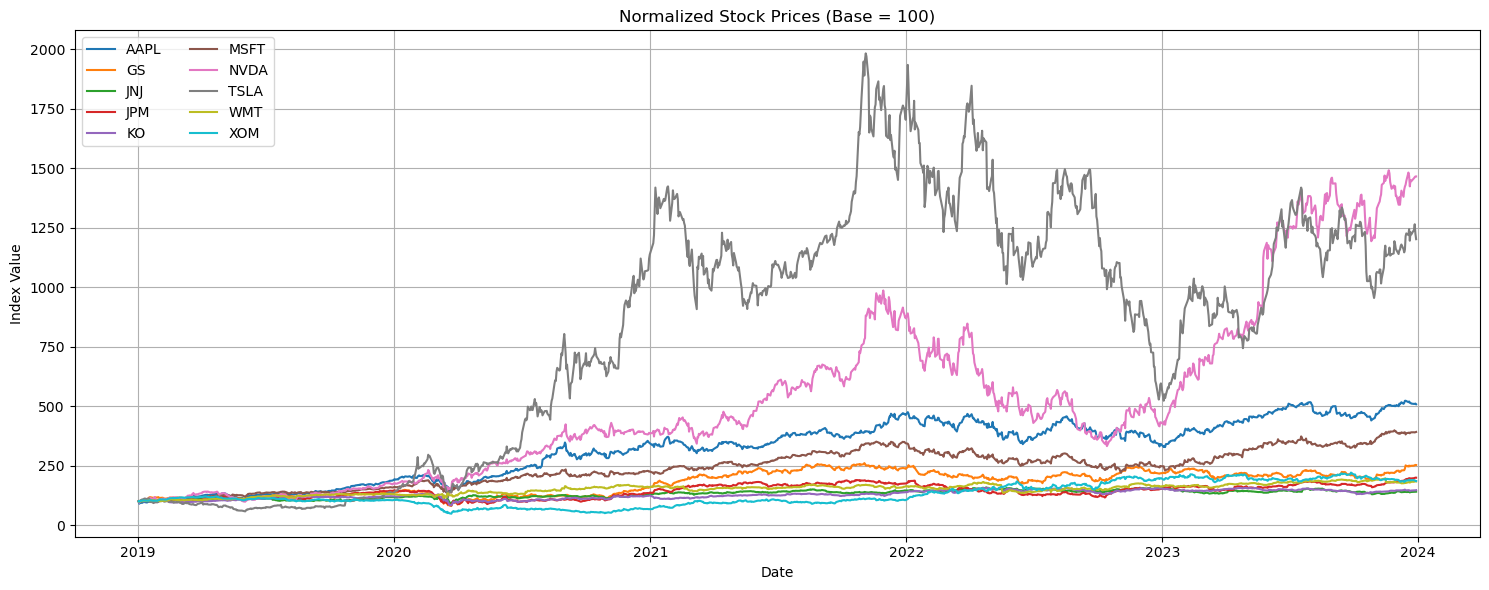

In [133]:
normalized = df / df.iloc[0] * 100

plt.figure(figsize=(15, 6))

for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)

plt.title("Normalized Stock Prices (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend(loc="upper left", ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()